Optimal R/S split with 0 Speed: Research 23%, Scale 77%


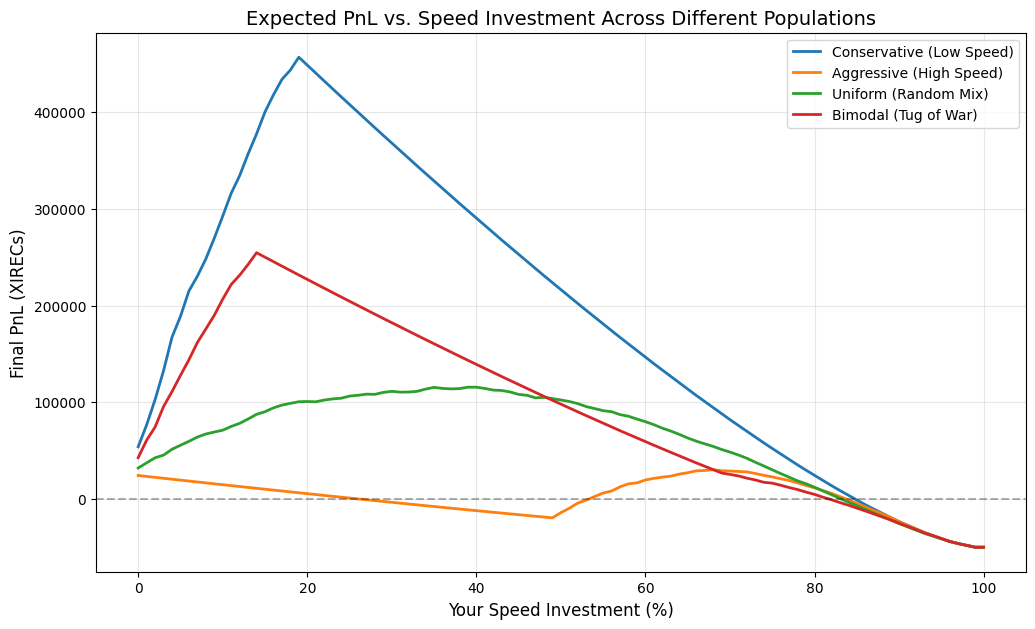

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants & Core Functions ---
TOTAL_BUDGET = 50_000
MAX_RESEARCH_VAL = 200_000
MAX_SCALE_VAL = 7

def get_research(x):
    """x is percentage (0-100)"""
    if x <= 0: return 0
    return MAX_RESEARCH_VAL * np.log(1 + x) / np.log(101)

def get_scale(y):
    """y is percentage (0-100)"""
    return MAX_SCALE_VAL * (y / 100)

def calculate_speed_multiplier(my_speed, population_speeds):
    """
    Calculates multiplier based on rank logic:
    Highest rank = 0.9, Lowest rank = 0.1, linear scaling in between.
    """
    all_speeds = np.array(list(population_speeds) + [my_speed])
    # Sort descending to determine rank
    sorted_speeds = np.sort(all_speeds)[::-1]
    
    # Standard competition ranking (1, 1, 1, 4...)
    # Find the first index where the value appears in the sorted array
    rank = np.where(sorted_speeds == my_speed)[0][0] + 1
    
    n = len(all_speeds)
    if n == 1: return 0.9 # Solo player case
    
    # Formula: 0.9 - (0.8 * (rank - 1) / (n - 1))
    multiplier = 0.9 - (0.8 * (rank - 1) / (n - 1))
    return multiplier

# --- Part A: Internal Optimization ---
def find_best_rs_split(speed_pct):
    """Finds the integer Research/Scale split for a fixed Speed investment."""
    remaining = 100 - speed_pct
    best_rs_product = -1
    best_x = 0
    
    for x in range(remaining + 1):
        y = remaining - x
        prod = get_research(x) * get_scale(y)
        if prod > best_rs_product:
            best_rs_product = prod
            best_x = x
            
    return best_x, remaining - best_x, best_rs_product

# --- Part B & C: Simulation and Plotting ---
def simulate_and_plot():
    # 1. Define Population Distributions (1000 players each)
    n_players = 1000
    distributions = {
        "Conservative (Low Speed)": np.random.randint(0, 20, n_players),
        "Aggressive (High Speed)": np.random.randint(50, 90, n_players),
        "Uniform (Random Mix)": np.random.randint(0, 100, n_players),
        "Bimodal (Tug of War)": np.concatenate([np.random.randint(0, 15, 500), 
                                               np.random.randint(70, 95, 500)])
    }

    speed_range = np.arange(0, 101, 1)
    results = {dist_name: [] for dist_name in distributions}

    for z in speed_range:
        # Find best internal split for this z
        r_pct, s_pct, rs_base = find_best_rs_split(z)
        
        for dist_name, pop in distributions.items():
            mult = calculate_speed_multiplier(z, pop)
            pnl = (rs_base * mult) - TOTAL_BUDGET
            results[dist_name].append(pnl)

    # Plotting
    plt.figure(figsize=(12, 7))
    for dist_name, pnls in results.items():
        plt.plot(speed_range, pnls, label=dist_name, linewidth=2)

    plt.title("Expected PnL vs. Speed Investment Across Different Populations", fontsize=14)
    plt.xlabel("Your Speed Investment (%)", fontsize=12)
    plt.ylabel("Final PnL (XIRECs)", fontsize=12)
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Highlight the R/S optimization finding
    opt_r, opt_s, _ = find_best_rs_split(0)
    print(f"Optimal R/S split with 0 Speed: Research {opt_r}%, Scale {opt_s}%")
    
    plt.show()

if __name__ == "__main__":
    simulate_and_plot()

In [10]:
# Interactive visualiser to find the ideal Research/Scale split for a given Speed investment.

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
%matplotlib inline
# Reuse the core functions from the previous block
def get_research(x):
    if x <= 0: return 0
    return 200_000 * np.log(1 + x) / np.log(101)

def get_scale(y):
    return 7 * (y / 100)

def plot_rs_optimization(speed_pct):
    remaining = 100 - speed_pct
    x_vals = np.arange(0, remaining + 1)
    
    # Calculate PnL for every possible integer Research allocation
    # PnL = (Research * Scale) - Budget
    pnls = []
    for x in x_vals:
        y = remaining - x
        base_pnl = (get_research(x) * get_scale(y)) - 50_000
        pnls.append(base_pnl)
    
    # Find optimum
    best_idx = np.argmax(pnls)
    best_x = x_vals[best_idx]
    max_pnl = pnls[best_idx]
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, pnls, color='#2ca02c', label='Base PnL (Pre-Multiplier)')
    plt.scatter(best_x, max_pnl, color='red', zorder=5, label=f'Optimum: {best_x}% Research')
    
    # Annotate the optimum
    plt.annotate(f'Best Split:\nRes: {best_x}%\nScale: {remaining-best_x}%', 
                 xy=(best_x, max_pnl), xytext=(best_x + 5, max_pnl - 50000),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.title(f"R/S Allocation PnL for Speed = {speed_pct}% (Remaining: {remaining}%)")
    plt.xlabel("Research Investment (%)")
    plt.ylabel("Base PnL (XIRECs)")
    plt.xlim(0, 100)
    plt.ylim(-60_000, 400_000) # Fixed scale for easier comparison
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# Create the interactive slider
interact(plot_rs_optimization, speed_pct=IntSlider(min=0, max=99, step=1, value=10));

interactive(children=(IntSlider(value=10, description='speed_pct', max=99), Output()), _dom_classes=('widget-i…

Task was destroyed but it is pending!
task: <Task pending name='Task-1026' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/yee/Documents/programs/engvenv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-1027' coro=<Kernel.shell_main() running at /home/yee/Documents/programs/engvenv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/yee/Documents/programs/engvenv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/lib/python3.12/collections/__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-1027' coro=<Kernel.shell_main() running at /home/yee/Documents/programs/engvenv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


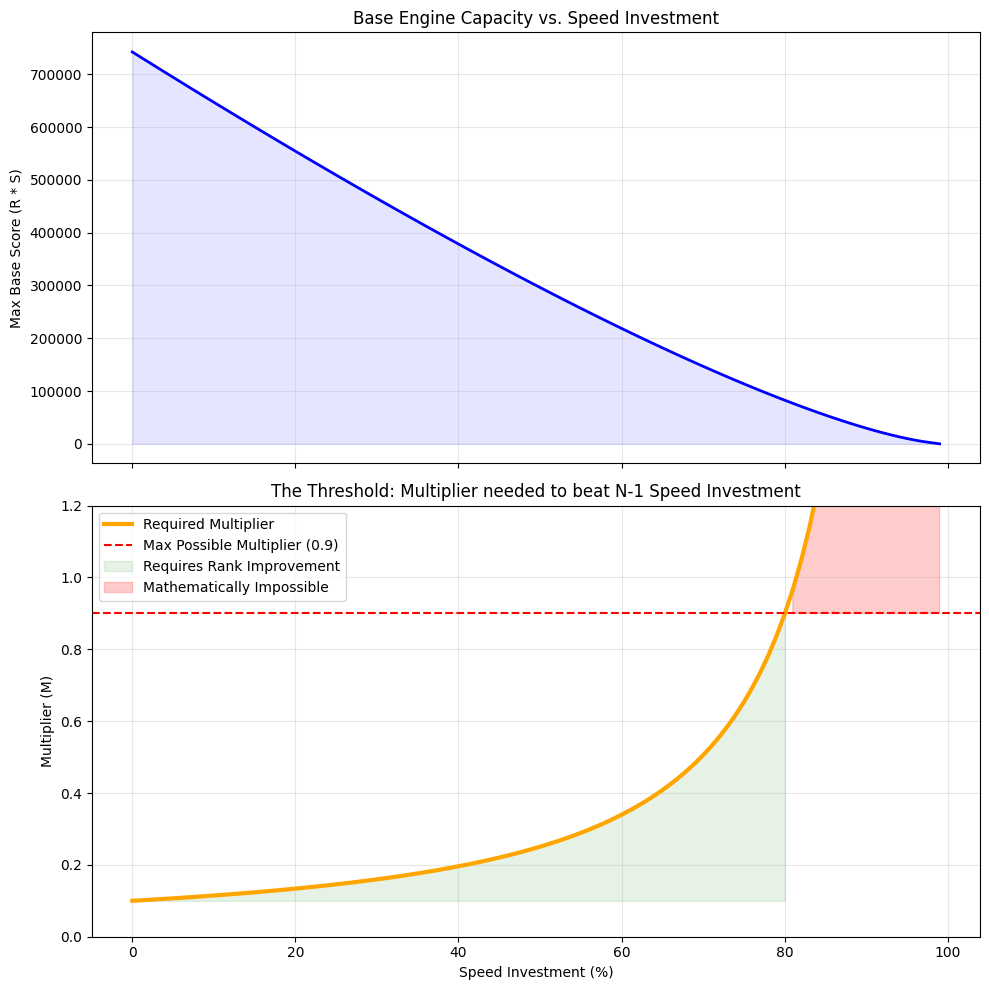

The Death Zone begins at 81% Speed.
Beyond this point, even getting Rank 1 (0.9 mult) is worse than Rank Last (0.1 mult) at 0% Speed.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
C_res = 200_000 / np.log(101)
C_scale = 7 / 100

def get_base_score(speed_pct):
    remaining = 100 - speed_pct
    if remaining <= 1: return 0.001 # Avoid div by zero
    
    # Fast optimization for R/S split
    # Peak is generally around 18-22% of total budget
    best_val = 0
    for x in np.linspace(0, remaining, 500):
        val = (C_res * np.log(1 + x)) * (C_scale * (remaining - x))
        if val > best_val:
            best_val = val
    return best_val

# Generate data
speeds = np.arange(0, 100, 1)
base_scores = np.array([get_base_score(s) for s in speeds])

# Iterative Multiplier Calculation
# Starting assumption: Speed 0 = 0.1 Multiplier (Last place)
m_required = [0.1]
for i in range(1, len(speeds)):
    # m_z = m_{z-1} * B(z-1) / B(z)
    next_m = m_required[-1] * (base_scores[i-1] / base_scores[i])
    m_required.append(next_m)

m_required = np.array(m_required)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Plot 1: The Engine Decay (R*S)
ax1.plot(speeds, base_scores, color='blue', lw=2)
ax1.set_ylabel("Max Base Score (R * S)")
ax1.set_title("Base Engine Capacity vs. Speed Investment")
ax1.grid(alpha=0.3)
ax1.fill_between(speeds, base_scores, color='blue', alpha=0.1)

# Plot 2: The Indifference Curve
ax2.plot(speeds, m_required, color='orange', lw=3, label="Required Multiplier")
ax2.axhline(0.9, color='red', linestyle='--', label="Max Possible Multiplier (0.9)")

# Shade the "Viable Zone" and "Death Zone"
ax2.fill_between(speeds, 0.1, m_required, where=(m_required <= 0.9), 
                 color='green', alpha=0.1, label="Requires Rank Improvement")
ax2.fill_between(speeds, 0.9, m_required, where=(m_required > 0.9), 
                 color='red', alpha=0.2, label="Mathematically Impossible")

ax2.set_ylim(0, 1.2)
ax2.set_ylabel("Multiplier (M)")
ax2.set_xlabel("Speed Investment (%)")
ax2.set_title("The Threshold: Multiplier needed to beat N-1 Speed Investment")
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find the "Death Zone" entry point
death_idx = np.where(m_required > 0.9)[0][0]
print(f"The Death Zone begins at {death_idx}% Speed.")
print(f"Beyond this point, even getting Rank 1 (0.9 mult) is worse than Rank Last (0.1 mult) at 0% Speed.")